Selected File: B_fc2f1fda51c24bdda91c1ff69f222289.dcm


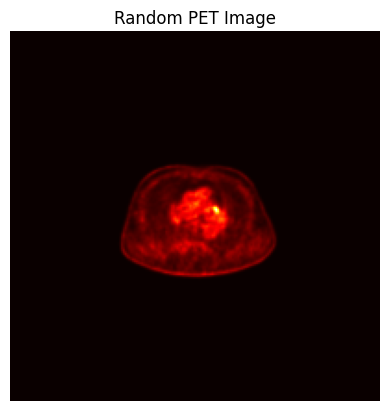

In [1]:
#Display Random PET Image

import os
import random
import pydicom
import matplotlib.pyplot as plt

path = "/kaggle/input/datasets/skarthik112/pet-image"

file = random.choice(os.listdir(path))

ds = pydicom.dcmread(os.path.join(path, file))

print("Selected File:", file)

plt.imshow(ds.pixel_array, cmap="hot")
plt.title("Random PET Image")
plt.axis("off")
plt.show()

Modality: PT
Shape: (200, 200)


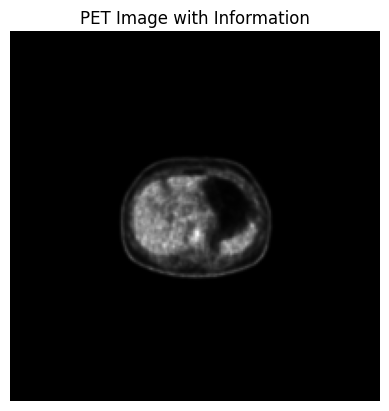

In [2]:
#Display PET Image Information

import os
import pydicom
import matplotlib.pyplot as plt

path = "/kaggle/input/datasets/skarthik112/pet-image"

file = os.listdir(path)[10]

ds = pydicom.dcmread(os.path.join(path, file))

print("Modality:", ds.Modality)
print("Shape:", ds.pixel_array.shape)

plt.imshow(ds.pixel_array, cmap="gray")
plt.title("PET Image with Information")
plt.axis("off")
plt.show()

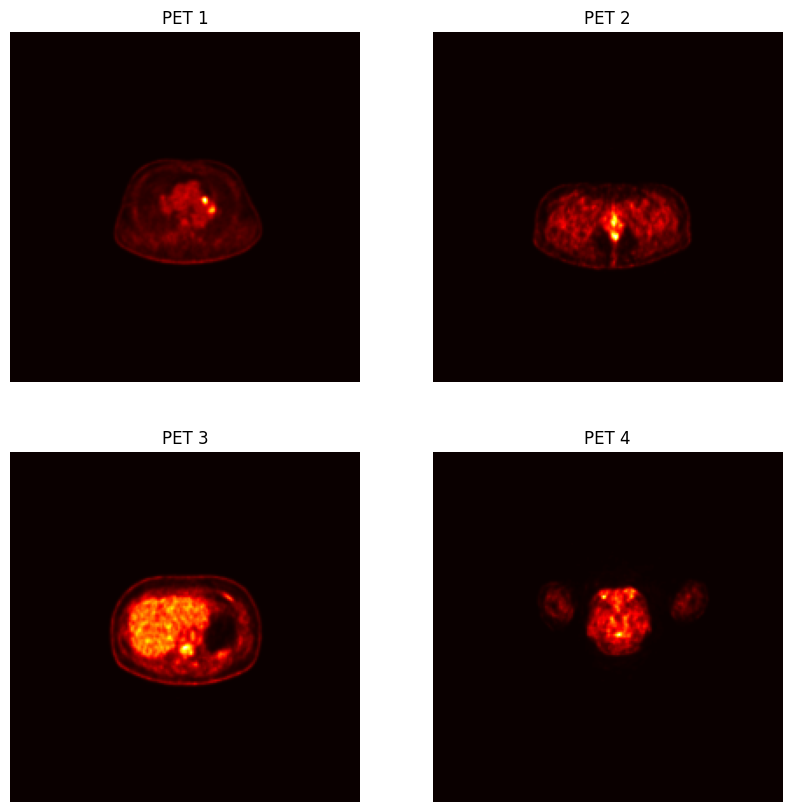

In [3]:
#Display Multiple PET Images


import os
import pydicom
import matplotlib.pyplot as plt

path = "/kaggle/input/datasets/skarthik112/pet-image"

files = os.listdir(path)[:4]

plt.figure(figsize=(10,10))

for i, file in enumerate(files):
    ds = pydicom.dcmread(os.path.join(path, file))

    plt.subplot(2,2,i+1)
    plt.imshow(ds.pixel_array, cmap="hot")
    plt.title(f"PET {i+1}")
    plt.axis("off")

plt.show()

DATASET INFORMATION
Total PET Images : 1699
Training Images   : 1189
Validation Images : 255
Testing Images    : 255


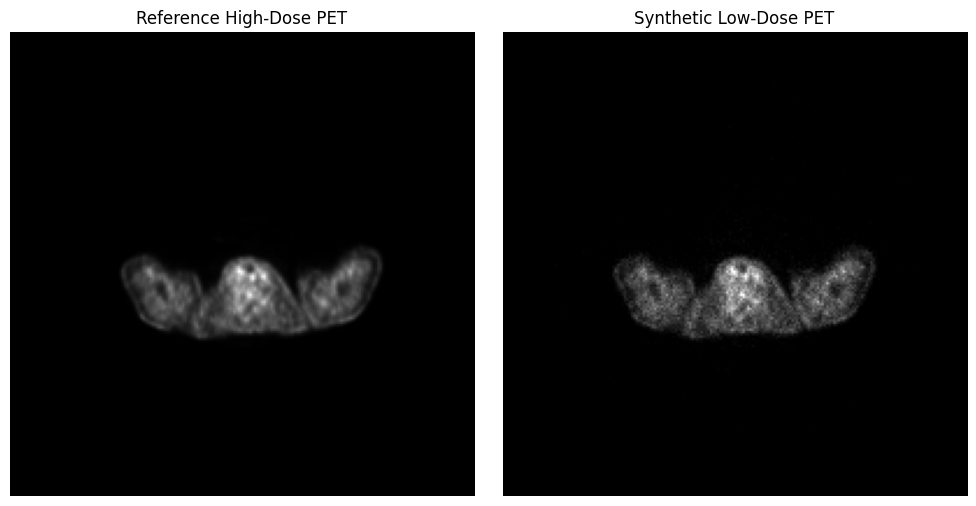

In [4]:

###### CELL 1



# =====================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================

import os
import numpy as np
import pydicom
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# =====================================================
# STEP 2: SET RANDOM SEED
# =====================================================

np.random.seed(42)
torch.manual_seed(42)

# =====================================================
# STEP 3: DEFINE DATASET PATH
# =====================================================

DATA_DIR = "/kaggle/input/datasets/skarthik112/pet-image"

# =====================================================
# STEP 4: READ ALL DICOM FILES
# =====================================================

files = sorted([
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if f.endswith(".dcm")
])

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print("Total PET Images :", len(files))

# =====================================================
# STEP 5: TRAIN / VALIDATION / TEST SPLIT (70/15/15)
# =====================================================

train_files, temp_files = train_test_split(
    files,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print(f"Training Images   : {len(train_files)}")
print(f"Validation Images : {len(val_files)}")
print(f"Testing Images    : {len(test_files)}")

# =====================================================
# STEP 6: LOAD PET IMAGE
# =====================================================

def load_pet(path):
    """
    Load DICOM PET image and normalize to [0,1].
    """
    ds = pydicom.dcmread(path)

    img = ds.pixel_array.astype(np.float32)

    img = img - img.min()
    img = img / (img.max() + 1e-8)

    return img

# =====================================================
# STEP 7: GENERATE SYNTHETIC LOW-DOSE PET
# =====================================================

def simulate_low_dose(img, reduction_factor=10):
    """
    Generate synthetic low-dose PET using Poisson noise.

    reduction_factor:
        4  -> Mild degradation
        10 -> Recommended
        20 -> Heavy degradation
    """

    img = img.astype(np.float32)
    img = img / (img.max() + 1e-8)

    counts = img * 1000.0
    counts = counts / reduction_factor

    noisy_counts = np.random.poisson(counts)

    low_img = noisy_counts / (1000.0 / reduction_factor)
    low_img = np.clip(low_img, 0, 1)

    return low_img

# =====================================================
# STEP 8: VISUALIZE SAMPLE IMAGE
# =====================================================

sample_high = load_pet(train_files[0])
sample_low = simulate_low_dose(sample_high, reduction_factor=10)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_high, cmap="gray")
plt.title("Reference High-Dose PET")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_low, cmap="gray")
plt.title("Synthetic Low-Dose PET")
plt.axis("off")

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 66.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 104.3 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatibl

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-06-20 05:10:40.319071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781932240.519142     103 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781932240.576109     103 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781932241.089516     103 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781932241.089555     103 computation_placer.cc:1

DATASET SUMMARY
Training Samples   : 1189
Validation Samples : 255
Testing Samples    : 255

✅ DataLoaders created successfully!

Batch Shapes
Low Dose  : torch.Size([4, 1, 200, 200])
High Dose : torch.Size([4, 1, 200, 200])


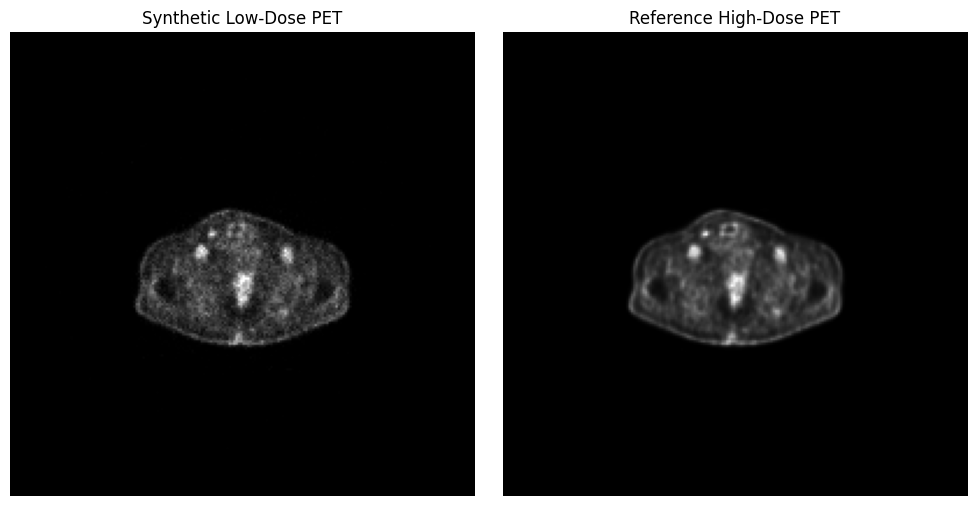


Using Device: cuda
Batch Size  : 4
✅ MONAI preprocessing enabled successfully!


In [5]:
#### CELL 2

!pip install -q monai

# =====================================================
# STEP 9: IMPORT REQUIRED LIBRARIES
# =====================================================

from torch.utils.data import Dataset, DataLoader
from monai.transforms import Compose, ScaleIntensity, EnsureType

# =====================================================
# STEP 10: DEFINE MONAI TRANSFORMS
# =====================================================

monai_transform = Compose([
    ScaleIntensity(),
    EnsureType()
])

# =====================================================
# STEP 11: CREATE CUSTOM PET DATASET
# =====================================================

class PETDataset(Dataset):

    def __init__(self, file_list):
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):

        # -----------------------------
        # Load High-Dose PET Image
        # -----------------------------
        high_img = load_pet(self.file_list[idx])

        # -----------------------------
        # Generate Synthetic Low-Dose PET
        # -----------------------------
        low_img = simulate_low_dose(
            high_img,
            reduction_factor=10
        )

        # -----------------------------
        # Apply MONAI Preprocessing
        # -----------------------------
        high_img = monai_transform(high_img)
        low_img = monai_transform(low_img)

        # -----------------------------
        # Convert to PyTorch Tensors
        # -----------------------------
        high_img = torch.as_tensor(
            high_img,
            dtype=torch.float32
        ).unsqueeze(0)

        low_img = torch.as_tensor(
            low_img,
            dtype=torch.float32
        ).unsqueeze(0)

        return low_img, high_img

# =====================================================
# STEP 12: CREATE DATASETS
# =====================================================

train_dataset = PETDataset(train_files)
val_dataset = PETDataset(val_files)
test_dataset = PETDataset(test_files)

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(val_dataset))
print("Testing Samples    :", len(test_dataset))

# =====================================================
# STEP 13: CREATE DATALOADERS
# =====================================================

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\n✅ DataLoaders created successfully!")

# =====================================================
# STEP 14: VERIFY BATCH SHAPES
# =====================================================

low_batch, high_batch = next(iter(train_loader))

print("\nBatch Shapes")
print("Low Dose  :", low_batch.shape)
print("High Dose :", high_batch.shape)

# Expected output:
# Low Dose  : torch.Size([4, 1, H, W])
# High Dose : torch.Size([4, 1, H, W])

# =====================================================
# STEP 15: VISUALIZE ONE TRAINING SAMPLE
# =====================================================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(low_batch[0, 0].cpu().numpy(), cmap="gray")
plt.title("Synthetic Low-Dose PET")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_batch[0, 0].cpu().numpy(), cmap="gray")
plt.title("Reference High-Dose PET")
plt.axis("off")

plt.tight_layout()
plt.show()

# =====================================================
# STEP 16: SET DEVICE
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nUsing Device:", device)
print("Batch Size  :", BATCH_SIZE)
print("✅ MONAI preprocessing enabled successfully!")

In [6]:

### CELL 3


# =====================================================
# STEP 16: INSTALL REQUIRED PACKAGES
# =====================================================

!pip -q install monai einops timm lmdb yacs natsort

# =====================================================
# STEP 17: DOWNLOAD RESTORMER REPOSITORY
# =====================================================

import os

if not os.path.exists("/kaggle/working/Restormer"):
    !git clone https://github.com/swz30/Restormer.git

# =====================================================
# STEP 18: IMPORT REQUIRED LIBRARIES
# =====================================================

import sys
import torch
import torch.nn as nn
import torch.optim as optim

sys.path.append("/kaggle/working/Restormer")

from basicsr.models.archs.restormer_arch import Restormer

# =====================================================
# STEP 19: INITIALIZE RESTORMER MODEL
# =====================================================

model = Restormer(

    inp_channels=1,
    out_channels=1,

    # Lightweight configuration
    dim=24,

    num_blocks=[2, 2, 2, 2],

    num_refinement_blocks=2,

    heads=[1, 2, 2, 4],

    ffn_expansion_factor=2.0,

    bias=False,

    LayerNorm_type="WithBias",

    dual_pixel_task=False

).to(device)

print("=" * 60)
print("RESTORMER MODEL INITIALIZED")
print("=" * 60)

# =====================================================
# STEP 20: DISPLAY MODEL INFORMATION
# =====================================================

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

# =====================================================
# STEP 21: DEFINE LOSS FUNCTION
# =====================================================

criterion = nn.L1Loss()

print("\nLoss Function : L1 Loss")

# =====================================================
# STEP 22: DEFINE OPTIMIZER
# =====================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer : AdamW")

# =====================================================
# STEP 23: DEFINE LEARNING RATE SCHEDULER
# =====================================================

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

print("Scheduler : CosineAnnealingLR")

# =====================================================
# STEP 24: TRAINING CONFIGURATION
# =====================================================

NUM_EPOCHS = 50   # Change to 100 if desired

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print("Epochs        :", NUM_EPOCHS)
print("Learning Rate :", 1e-4)
print("Batch Size    :", BATCH_SIZE)
print("Device        :", device)

print("\n✅ Model setup completed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.3/338.3 kB 17.1 MB/s eta 0:00:00
Cloning into 'Restormer'...
remote: Enumerating objects: 312, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 312 (delta 78), reused 76 (delta 76), pack-reused 189 (from 1)
Receiving objects: 100% (312/312), 1.55 MiB | 27.32 MiB/s, done.
Resolving deltas: 100% (131/131), done.
RESTORMER MODEL INITIALIZED
Total Parameters     : 2,331,222
Trainable Parameters : 2,331,222

Loss Function : L1 Loss
Optimizer : AdamW
Scheduler : CosineAnnealingLR
TRAINING CONFIGURATION
Epochs        : 50
Learning Rate : 0.0001
Batch Size    : 4
Device        : cuda

✅ Model setup completed successfully!


In [7]:
### CELL 4




# =====================================================
# STEP 25: IMPORT REQUIRED LIBRARIES
# =====================================================

from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
import numpy as np
import torch

# =====================================================
# STEP 26: INITIALIZE TRAINING VARIABLES
# =====================================================

best_loss = float("inf")

train_losses = []
val_losses = []

psnr_history = []
ssim_history = []

# =====================================================
# STEP 27: START TRAINING
# =====================================================

for epoch in range(NUM_EPOCHS):

    print("\n" + "=" * 60)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]")
    print("=" * 60)

    # -------------------------------------------------
    # TRAINING PHASE
    # -------------------------------------------------

    model.train()

    running_loss = 0.0

    progress_bar = tqdm(train_loader)

    for low_img, high_img in progress_bar:

        low_img = low_img.to(device)
        high_img = high_img.to(device)

        optimizer.zero_grad()

        pred = model(low_img)

        loss = criterion(pred, high_img)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_postfix(
            Train_Loss=f"{loss.item():.6f}"
        )

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    # -------------------------------------------------
    # VALIDATION PHASE
    # -------------------------------------------------

    model.eval()

    val_running_loss = 0.0

    psnr_epoch = []
    ssim_epoch = []

    with torch.no_grad():

        for low_img, high_img in val_loader:

            low_img = low_img.to(device)
            high_img = high_img.to(device)

            pred = model(low_img)

            loss = criterion(pred, high_img)

            val_running_loss += loss.item()

            # -----------------------------------------
            # Compute metrics for each image in batch
            # -----------------------------------------

            batch_size = pred.shape[0]

            for i in range(batch_size):

                pred_np = pred[i, 0].cpu().numpy()
                gt_np = high_img[i, 0].cpu().numpy()

                pred_np = np.clip(pred_np, 0, 1)
                gt_np = np.clip(gt_np, 0, 1)

                psnr_epoch.append(
                    peak_signal_noise_ratio(
                        gt_np,
                        pred_np,
                        data_range=1.0
                    )
                )

                ssim_epoch.append(
                    structural_similarity(
                        gt_np,
                        pred_np,
                        data_range=1.0,
                        win_size=7
                    )
                )

    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)

    avg_psnr = np.mean(psnr_epoch)
    avg_ssim = np.mean(ssim_epoch)

    psnr_history.append(avg_psnr)
    ssim_history.append(avg_ssim)

    scheduler.step()

    # -------------------------------------------------
    # PRINT RESULTS
    # -------------------------------------------------

    print(f"Training Loss   : {train_loss:.6f}")
    print(f"Validation Loss : {val_loss:.6f}")
    print(f"Validation PSNR : {avg_psnr:.4f}")
    print(f"Validation SSIM : {avg_ssim:.4f}")

    # -------------------------------------------------
    # SAVE BEST MODEL
    # -------------------------------------------------

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_restormer_pet.pth"
        )

        print("✅ Best model saved successfully!")

# =====================================================
# STEP 28: TRAINING COMPLETED
# =====================================================

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(f"Best Validation Loss : {best_loss:.6f}")
print("Saved Model          : /kaggle/working/best_restormer_pet.pth")


Epoch [1/50]


100%|██████████| 298/298 [02:29<00:00,  2.00it/s, Train_Loss=0.004669]


Training Loss   : 0.008379
Validation Loss : 0.004612
Validation PSNR : 40.5106
Validation SSIM : 0.9651
✅ Best model saved successfully!

Epoch [2/50]


100%|██████████| 298/298 [02:33<00:00,  1.94it/s, Train_Loss=0.002981]


Training Loss   : 0.004208
Validation Loss : 0.003764
Validation PSNR : 41.8554
Validation SSIM : 0.9681
✅ Best model saved successfully!

Epoch [3/50]


...

Training Loss   : 0.001584
Validation Loss : 0.001588
Validation PSNR : 43.8994
Validation SSIM : 0.9941

Epoch [49/50]


100%|██████████| 298/298 [02:33<00:00,  1.94it/s, Train_Loss=0.000755]


Training Loss   : 0.001575
Validation Loss : 0.001591
Validation PSNR : 43.8933
Validation SSIM : 0.9940

Epoch [50/50]


100%|██████████| 298/298 [02:32<00:00,  1.95it/s, Train_Loss=0.001538]


Training Loss   : 0.001575
Validation Loss : 0.001565
Validation PSNR : 44.0202
Validation SSIM : 0.9941
✅ Best model saved successfully!

TRAINING COMPLETED
Best Validation Loss : 0.001565
Saved Model          : /kaggle/working/best_restormer_pet.pth


✅ Best Restormer model loaded successfully!


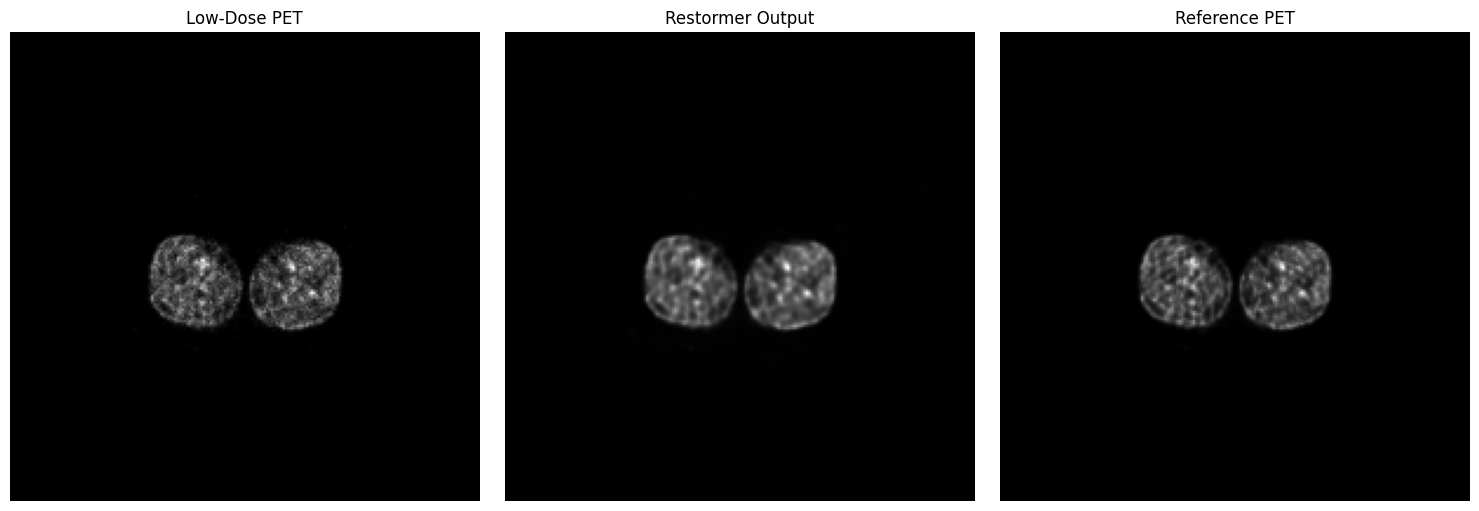


FINAL TEST RESULTS
Average PSNR  : 43.8574 dB
Average SSIM  : 0.9939
Average RMSE  : 0.006750
Average NRMSE : 0.006750


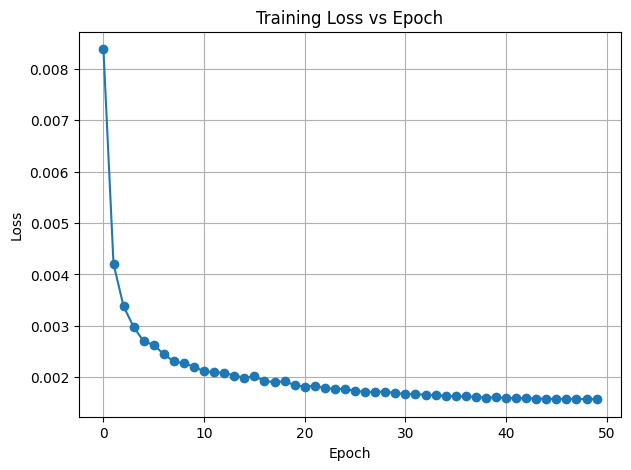

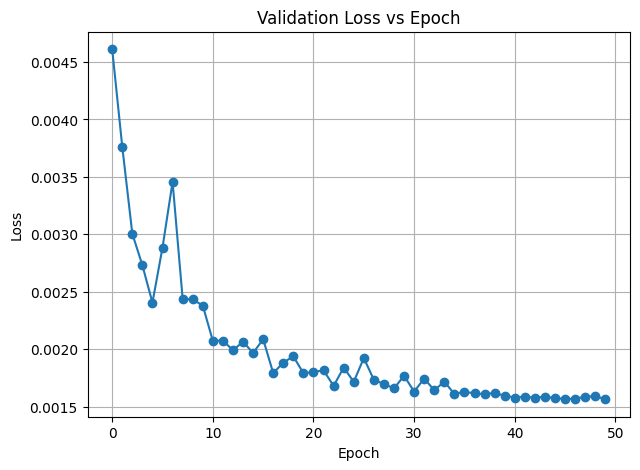

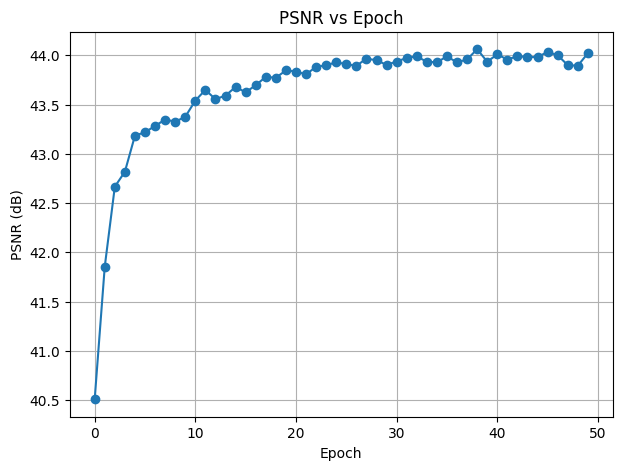

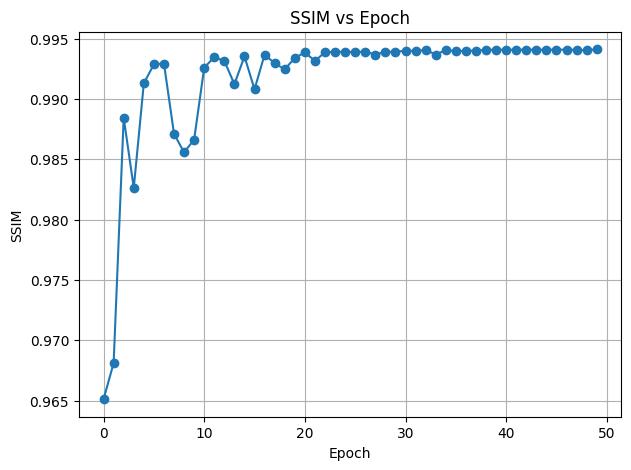


✅ PROJECT COMPLETED SUCCESSFULLY!


In [8]:
# =====================================================
# STEP 29: IMPORT REQUIRED LIBRARIES
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import mean_squared_error
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

# =====================================================
# STEP 30: LOAD BEST TRAINED MODEL
# =====================================================

checkpoint = torch.load(
    "/kaggle/working/best_restormer_pet.pth",
    map_location=device
)

model.load_state_dict(checkpoint)
model.to(device)
model.eval()

print("✅ Best Restormer model loaded successfully!")

# =====================================================
# STEP 31: VISUALIZE ONE TEST SAMPLE
# =====================================================

low_img, high_img = next(iter(test_loader))

low_img = low_img.to(device)
high_img = high_img.to(device)

with torch.no_grad():
    restored = model(low_img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(low_img[0,0].cpu().numpy(), cmap="gray")
plt.title("Low-Dose PET")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(restored[0,0].cpu().numpy(), cmap="gray")
plt.title("Restormer Output")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(high_img[0,0].cpu().numpy(), cmap="gray")
plt.title("Reference PET")
plt.axis("off")

plt.tight_layout()
plt.show()

# =====================================================
# STEP 32: EVALUATE MODEL
# =====================================================

psnr_list = []
ssim_list = []
rmse_list = []
nrmse_list = []

with torch.no_grad():

    for low_img, high_img in test_loader:

        low_img = low_img.to(device)
        high_img = high_img.to(device)

        pred = model(low_img)

        for i in range(pred.shape[0]):

            pred_np = pred[i,0].cpu().numpy()
            gt_np = high_img[i,0].cpu().numpy()

            pred_np = np.nan_to_num(pred_np)
            gt_np = np.nan_to_num(gt_np)

            pred_np = np.clip(pred_np, 0, 1)
            gt_np = np.clip(gt_np, 0, 1)

            # -----------------------
            # PSNR
            # -----------------------

            psnr = peak_signal_noise_ratio(
                gt_np,
                pred_np,
                data_range=1.0
            )

            # -----------------------
            # SSIM
            # -----------------------

            ssim = structural_similarity(
                gt_np,
                pred_np,
                data_range=1.0,
                win_size=7
            )

            # -----------------------
            # RMSE
            # -----------------------

            mse = mean_squared_error(
                gt_np.flatten(),
                pred_np.flatten()
            )

            rmse = np.sqrt(mse)

            # -----------------------
            # NRMSE
            # -----------------------

            nrmse = rmse / (gt_np.max() - gt_np.min() + 1e-8)

            psnr_list.append(psnr)
            ssim_list.append(ssim)
            rmse_list.append(rmse)
            nrmse_list.append(nrmse)

# =====================================================
# STEP 33: PRINT FINAL RESULTS
# =====================================================

print("\n" + "="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Average PSNR  : {np.mean(psnr_list):.4f} dB")
print(f"Average SSIM  : {np.mean(ssim_list):.4f}")
print(f"Average RMSE  : {np.mean(rmse_list):.6f}")
print(f"Average NRMSE : {np.mean(nrmse_list):.6f}")

# =====================================================
# STEP 34: TRAINING LOSS GRAPH
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(train_losses, marker="o")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# =====================================================
# STEP 35: VALIDATION LOSS GRAPH
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(val_losses, marker="o")
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# =====================================================
# STEP 36: PSNR GRAPH
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(psnr_history, marker="o")
plt.title("PSNR vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.show()

# =====================================================
# STEP 37: SSIM GRAPH
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(ssim_history, marker="o")
plt.title("SSIM vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.grid(True)
plt.show()

print("\n✅ PROJECT COMPLETED SUCCESSFULLY!")

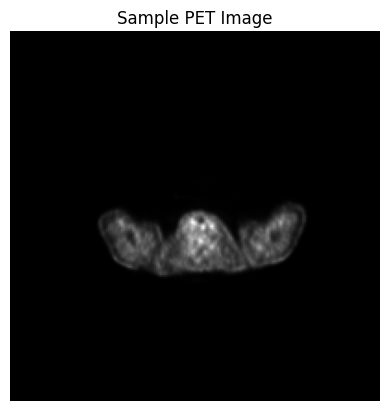

In [9]:
import matplotlib.pyplot as plt

img = load_pet(train_files[0])

plt.imshow(img, cmap="gray")
plt.title("Sample PET Image")
plt.axis("off")
plt.show()

In [10]:
# =====================================================
# CELL 6: SAVE PROJECT FILES
# =====================================================

import os
import shutil

save_dir = "/kaggle/working/project_results"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# Copy trained model
# -----------------------------
model_path = "/kaggle/working/best_restormer_pet.pth"

if os.path.exists(model_path):
    shutil.copy(model_path, os.path.join(save_dir, "best_restormer_pet.pth"))
    print("✅ Model copied.")
else:
    print("❌ Model file not found.")

# -----------------------------
# Save final metrics
# -----------------------------
with open(os.path.join(save_dir, "final_results.txt"), "w") as f:
    f.write("FINAL TEST RESULTS\n")
    f.write("=============================\n")
    f.write(f"Average PSNR  : {np.mean(psnr_list):.4f} dB\n")
    f.write(f"Average SSIM  : {np.mean(ssim_list):.4f}\n")
    f.write(f"Average RMSE  : {np.mean(rmse_list):.6f}\n")
    f.write(f"Average NRMSE : {np.mean(nrmse_list):.6f}\n")

print("✅ Metrics saved.")

# -----------------------------
# Save training loss graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(train_losses, marker="o")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(os.path.join(save_dir, "training_loss.png"), dpi=300)
plt.close()

# -----------------------------
# Save validation loss graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(val_losses, marker="o")
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(os.path.join(save_dir, "validation_loss.png"), dpi=300)
plt.close()

# -----------------------------
# Save PSNR graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(psnr_history, marker="o")
plt.title("PSNR vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("PSNR")
plt.grid(True)
plt.savefig(os.path.join(save_dir, "psnr_graph.png"), dpi=300)
plt.close()

# -----------------------------
# Save SSIM graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(ssim_history, marker="o")
plt.title("SSIM vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.grid(True)
plt.savefig(os.path.join(save_dir, "ssim_graph.png"), dpi=300)
plt.close()

print("\n===================================")
print("✅ ALL FILES SAVED SUCCESSFULLY!")
print("===================================")
print("Saved folder:", save_dir)
print("\nFiles:")
print("- best_restormer_pet.pth")
print("- final_results.txt")
print("- training_loss.png")
print("- validation_loss.png")
print("- psnr_graph.png")
print("- ssim_graph.png")

✅ Model copied.
✅ Metrics saved.

✅ ALL FILES SAVED SUCCESSFULLY!
Saved folder: /kaggle/working/project_results

Files:
- best_restormer_pet.pth
- final_results.txt
- training_loss.png
- validation_loss.png
- psnr_graph.png
- ssim_graph.png
